# Modelo de Ising

Durante este trabajo, vamos a trabajar con el modelo de Ising...

Para comenzar, haremos algunas mediciones preliminares. Esto tiene como objetivos:
- Medir el tiempo de termalización de cada sistema.
- Medir el tiempo de autocorrelación de cada sistema.

Como estos tiempos característicos son máximos cerca del punto crítico (que sabemos es cercano a $2.27$), hemos hecho simulaciones con $T=2.27$ para cada valor de $L$. 

Empezamos descargando las librerías necesarias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

Y ahora vamos a graficar la energía por espín y la magnetización por espín para cada $L$ cerca del punto crítico.

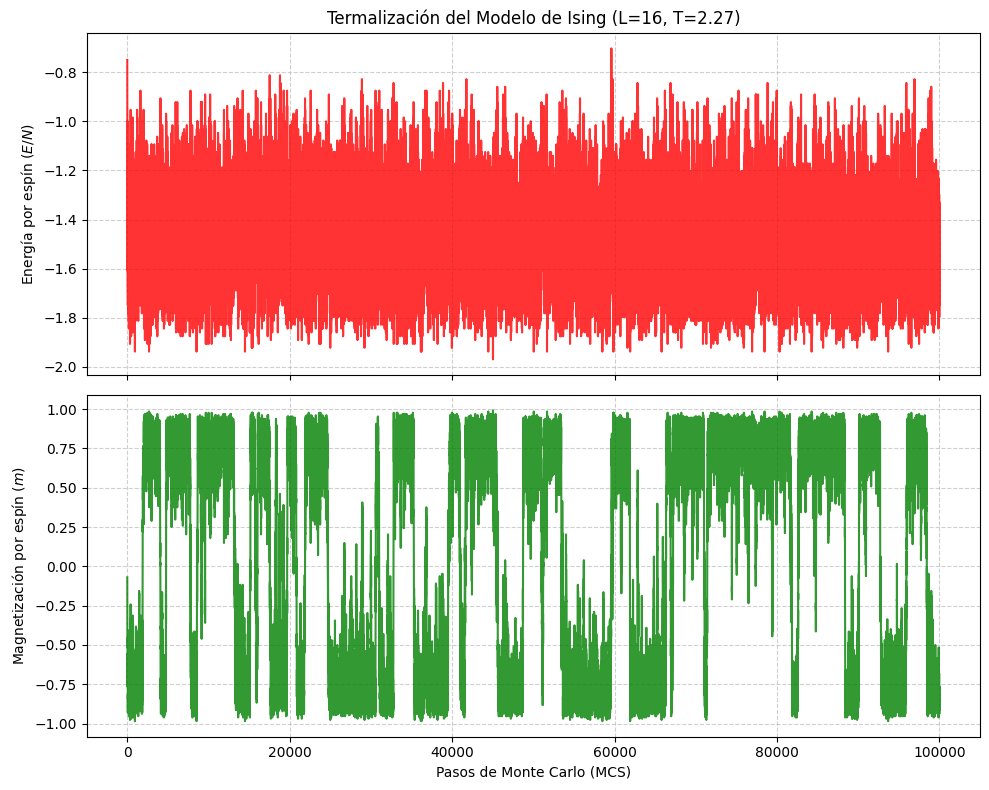

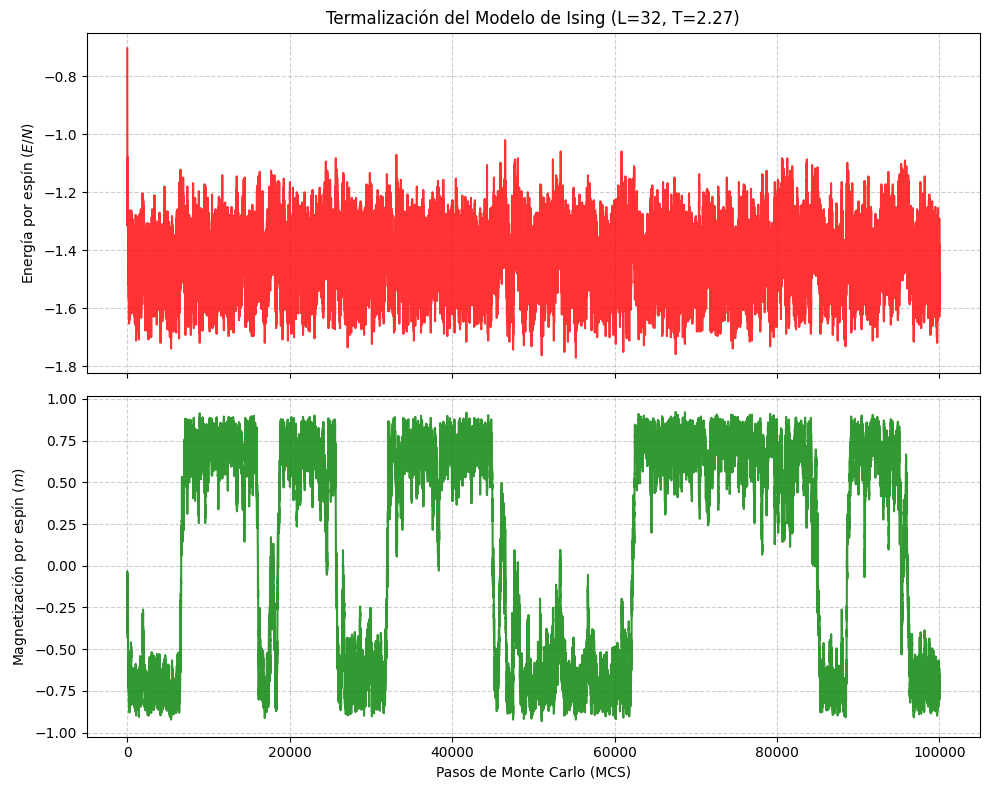

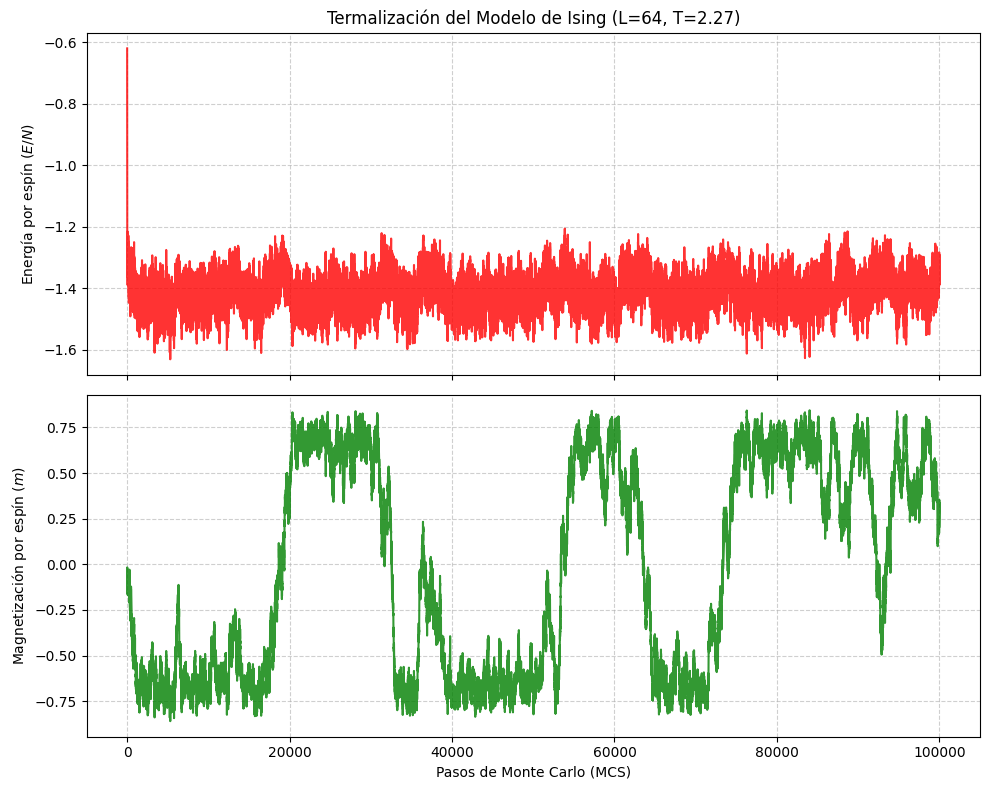

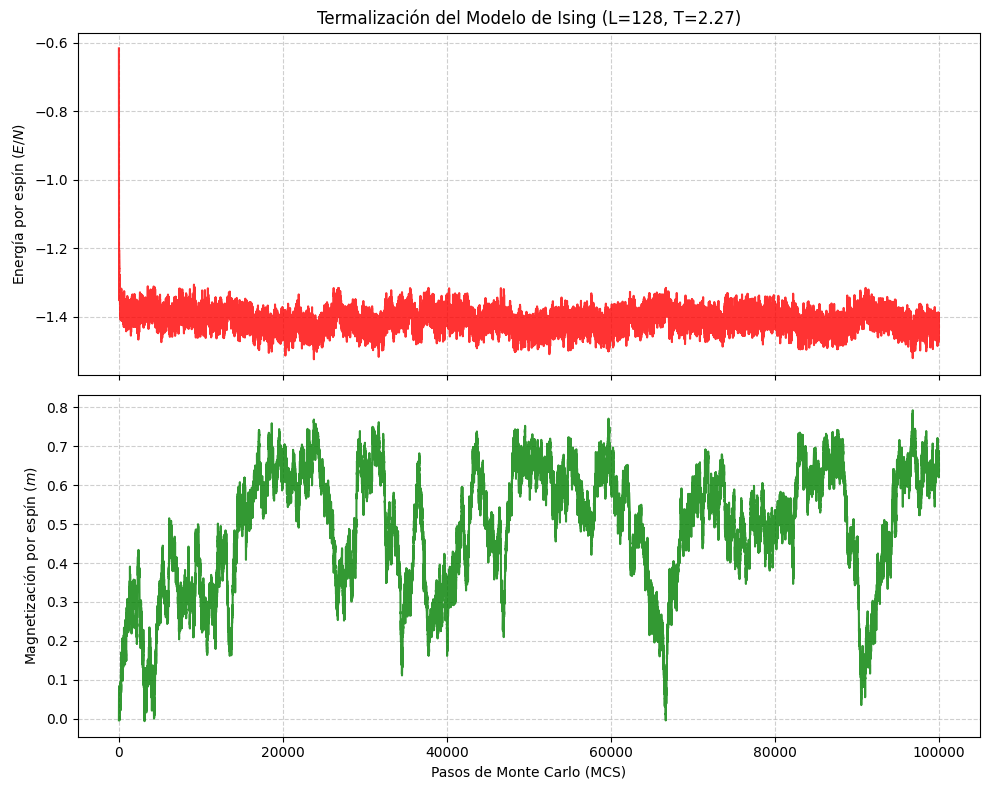

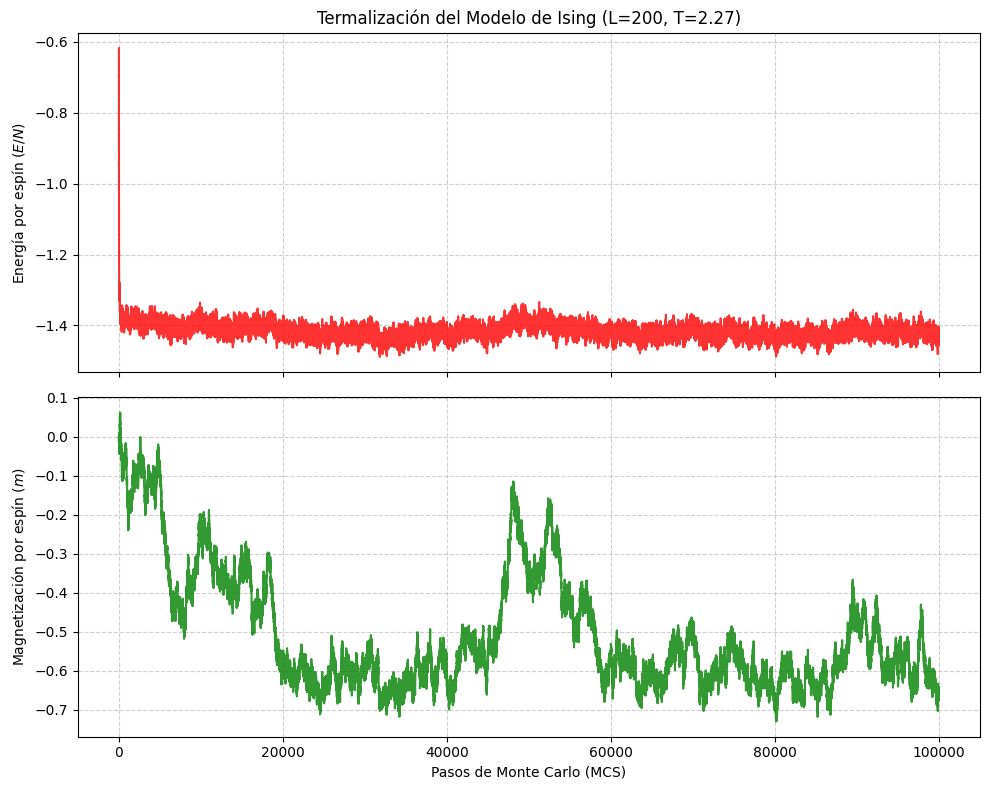

In [2]:
# Create a list with the sides of the simulation
side_list = [16, 32, 64, 128, 200]

# Create folder to store the images
graph_folder = f"preliminar_graphs"
os.makedirs(graph_folder, exist_ok=True)

for side in side_list: 
    # Load data
    archivo = f"preliminar_data/data_thermalization_L={side}.csv"
    df = pd.read_csv(archivo)

    # Create the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Energy plot
    ax1.plot(df['MCS'], df['Energy_per_spin'], color = 'red', alpha=0.8)
    ax1.set_ylabel('Energía por espín ($E/N$)')
    ax1.set_title(f'Termalización del Modelo de Ising (L={side}, T=2.27)')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Magnetization plot
    ax2.plot(df['MCS'], df['Mag_per_spin'], color = 'green', alpha=0.8)
    ax2.set_ylabel('Magnetización por espín ($m$)')
    ax2.set_xlabel('Pasos de Monte Carlo (MCS)')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Save the figure and plot
    plt.savefig(f"{graph_folder}/thermalization_L={side}.png", dpi = 600)
    plt.tight_layout()
    plt.show()

Es interesante notar que para las simulaciones con $L$ pequeño, se puede ver que hay puntos donde hay fluctuaciones altas en la magnetización y su valor cambia de un valor positivo a uno negativo. Esto sucede por la hergodicidad del sistema y el tiempo que pasa entre estos cambios abruptos se llama tiempo de escape. Esto no puede verse tanto en los sistemas más grandes porque, al tender $L$ al infinito, el tiempo de escape tiende a infinito también. 

En los gráficos de la energía puede verse correctamente como el sistema parece haber termalizado pronto. Además, notemos que el valor de la energía por espín llega a un estado estacionario cercano a $e=-1.4$ para todo tamaño de sistema. Se sabe [poner bibliografía...] que la energía por espín a la temperatura crítica es $e=- \sqrt2 J$ que coincide con las simulaciones para $J=1$.

Para elegir de mejor manera el Tiempo de Termalización $T_t$, veamos con un zoom los gráficos para $L=200$ que, al ser el sistema más grande, también es el que más tarda en termalizar.  

Leyendo preliminar_data/data_thermalization_L=200.csv...


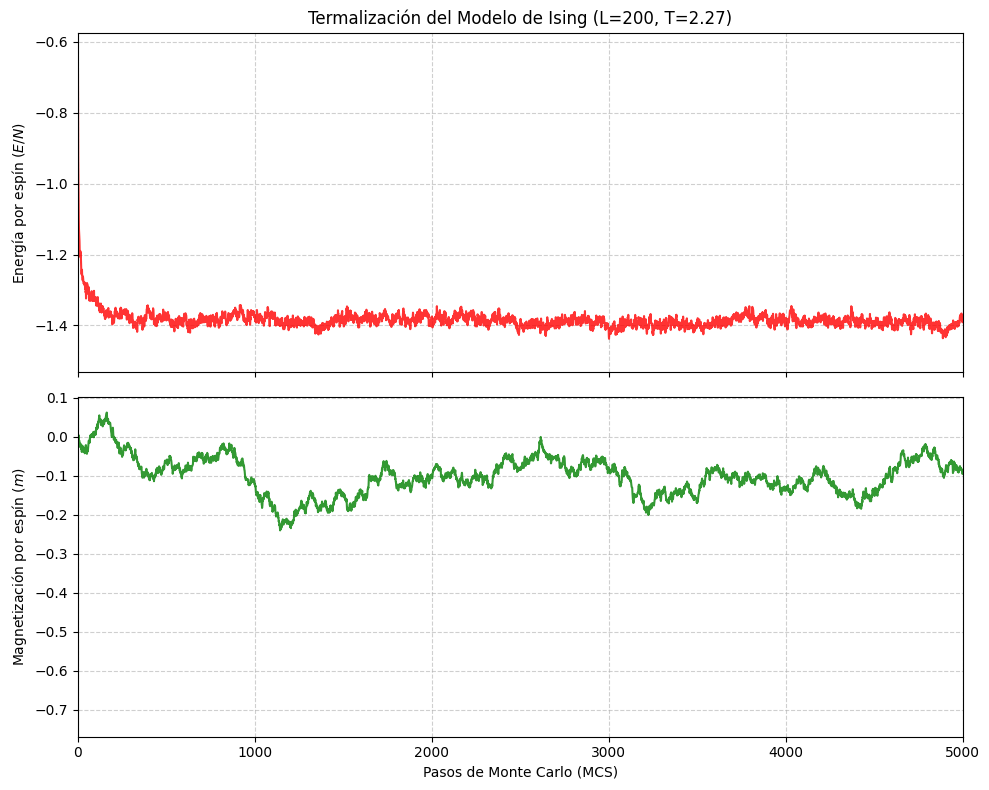

In [3]:
# Choose the side
side = 200

# Load data
archivo = f"preliminar_data/data_thermalization_L={side}.csv"
print(f"Leyendo {archivo}...")
df = pd.read_csv(archivo)

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Energy plot
ax1.plot(df['MCS'], df['Energy_per_spin'], color = 'red', alpha=0.8) #, color='crimson', alpha=0.8
ax1.set_ylabel('Energía por espín ($E/N$)')
ax1.set_title(f'Termalización del Modelo de Ising (L={side}, T=2.27)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Magnetization plot
ax2.plot(df['MCS'], df['Mag_per_spin'], color = 'green', alpha=0.8) # , color='dodgerblue', alpha=0.8
ax2.set_ylabel('Magnetización por espín ($m$)')
ax2.set_xlabel('Pasos de Monte Carlo (MCS)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(0, 5000)

# Save the figure and plot
plt.savefig(f"{graph_folder}/thermalization_L={side}_zoom.png", dpi = 600)
plt.tight_layout()
plt.show()

Acá puede verse que para $500$ pasos el sistema ya parece haber termalizado. Ahora, podemos calcular el tiempo de autocorrelación, que va a ser el tiempo que hay que esperar para que la configuración del sistema sea independiente a la anterior.

Leyendo preliminar_data/data_thermalization_L=16.csv...


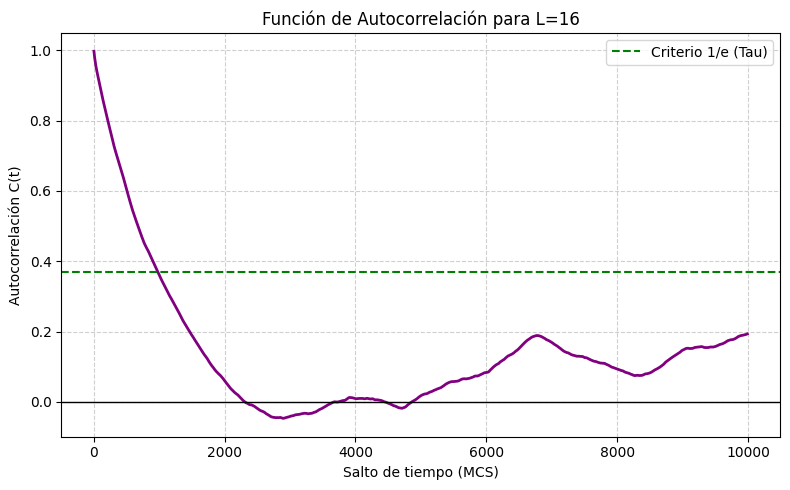

Leyendo preliminar_data/data_thermalization_L=32.csv...


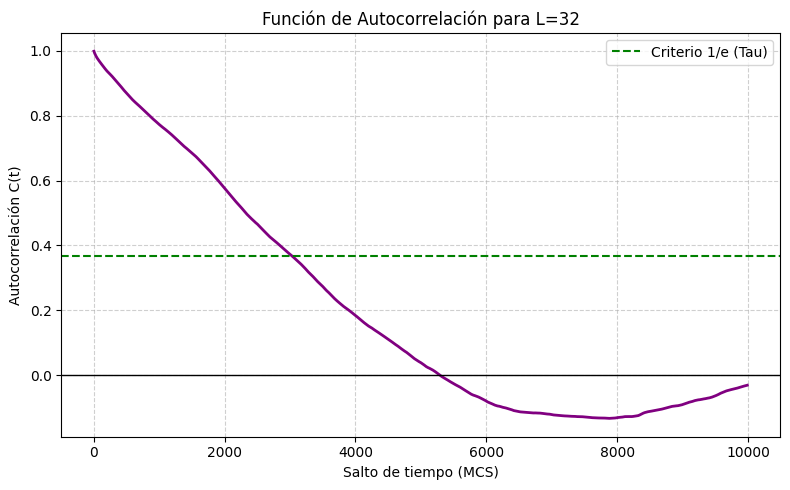

Leyendo preliminar_data/data_thermalization_L=64.csv...


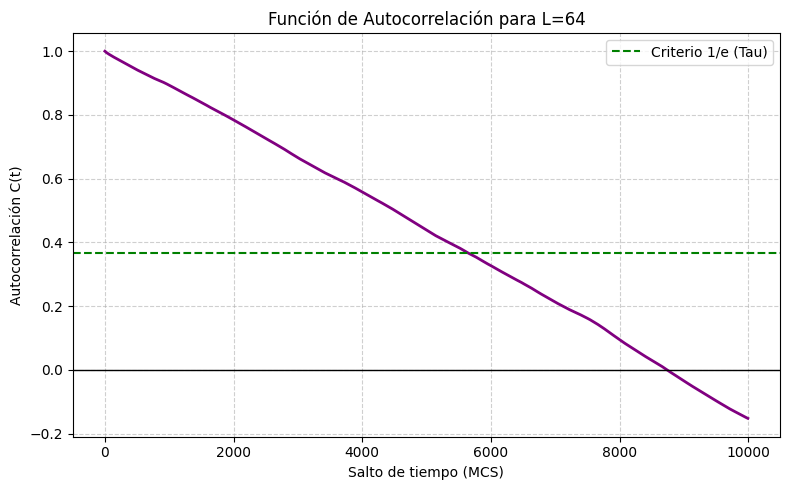

Leyendo preliminar_data/data_thermalization_L=128.csv...


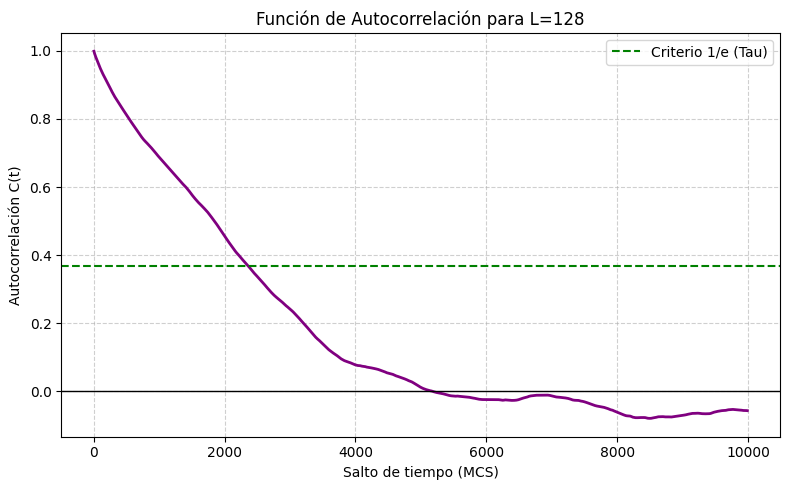

Leyendo preliminar_data/data_thermalization_L=200.csv...


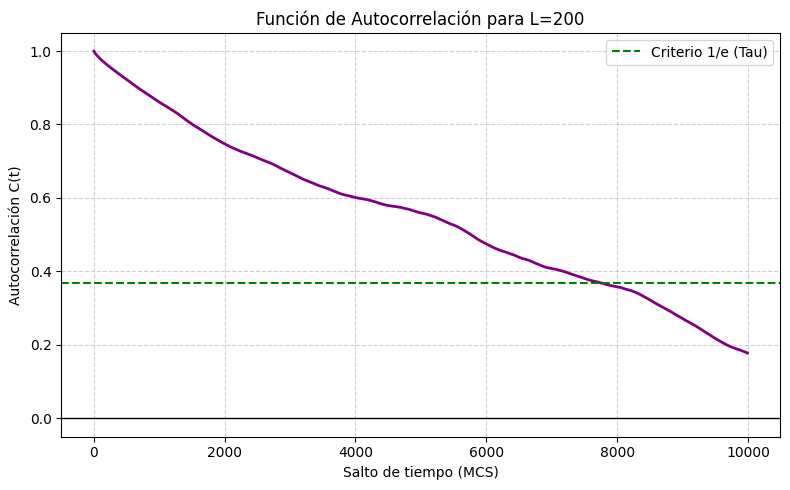

In [4]:
# 1. Elegí el tamaño de red
time = 10_000
side_list = [16, 32, 64, 128, 200]
for side in side_list:
    # 2. Cargamos los datos
    archivo = f"preliminar_data/data_thermalization_L={side}.csv"
    print(f"Leyendo {archivo}...")
    df = pd.read_csv(archivo)

    # 3. Tiramos la termalización (los primeros 1000 pasos)
    # Nos quedamos con la serie de tiempo equilibrada
    m_equilibrada = df['Mag_per_spin'][1000:]

    # 4. Calculamos la autocorrelación para distintos "saltos" de tiempo (lags)
    # Para L=64 probamos saltos de a 10 pasos hasta los 2000 pasos
    lags = np.arange(1, time, 10) 
    # La funcion autocorr mide la autocorrelación de Pearson 
    autocorr = [m_equilibrada.autocorr(lag=lag) for lag in lags]

    # 5. Graficamos
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(lags, autocorr, color='purple', linewidth=2)

    # Líneas de referencia
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(0.368, color='green', linestyle='--', label='Criterio 1/e (Tau)')

    ax.set_title(f'Función de Autocorrelación para L={side}')
    ax.set_xlabel('Salto de tiempo (MCS)')
    ax.set_ylabel('Autocorrelación C(t)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.savefig(f"{graph_folder}/autocorrelation_L={side}_time={time}.png", dpi=600)
    plt.tight_layout()
    plt.show()

Acá vemos que en el peor de los casos, el tiempo de autocorrelación es de $8.000$ MCS. Por lo tanto, tomamos las siguientes decisiones:
- Tiempo de termalización: $10.000$ MCS. Eso hace que pase tiempo considerable para que la energía llegue a su estado estacionario y, además, supera el tiempo de autocorrelación.
- Tiempo final de la simulación: $150.000$ MCS. Si el número de muestras independientes es $N_{eff}$ y el tiempo total de medición es $t$ entonces:

$$
N_{eff} = \frac{t}{2 \tau},
$$

con $\tau$ el tiempo de autocorrelación. En el peor de los casos, tenemos aproximadamente $10$ muestras independientes y este número aumenta mucho lejos de la temperatura crítica.
- Tiempo de muestreo: Cada $50$ pasos tendremos buena cantidad de puntos para estadística.